170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 52s 0us/step


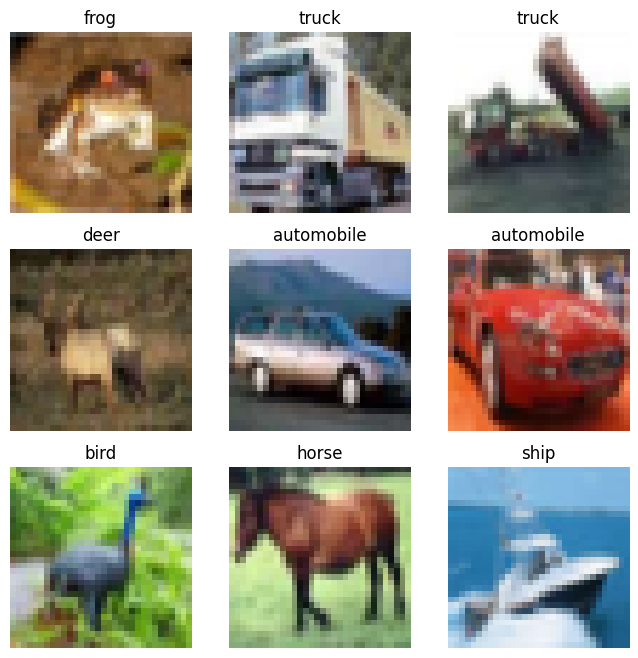

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 73s 45ms/step - accuracy: 0.4445 - loss: 1.5137 - val_accuracy: 0.5597 - val_loss: 1.2344
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 70s 45ms/step - accuracy: 0.5950 - loss: 1.1426 - val_accuracy: 0.6054 - val_loss: 1.1312
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 70s 45ms/step - accuracy: 0.6496 - loss: 0.9967 - val_accuracy: 0.6339 - val_loss: 1.0499
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 70s 45ms/step - accuracy: 0.6806 - loss: 0.9073 - val_accuracy: 0.6788 - val_loss: 0.9206
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 71s 46ms/step - accuracy: 0.7067 - loss: 0.8339 - val_accuracy: 0.6810 - val_loss: 0.9214
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 70s 45ms/step - accuracy: 0.7276 - loss: 0.7778 - val_accuracy: 0.6696 - val_loss: 0.9738
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 44ms/step - accuracy: 0.7462 - loss: 0.7248 - val_accuracy: 0.6947 - val_loss: 0.9028
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 70s 45ms/step - accuracy: 0.7603 -

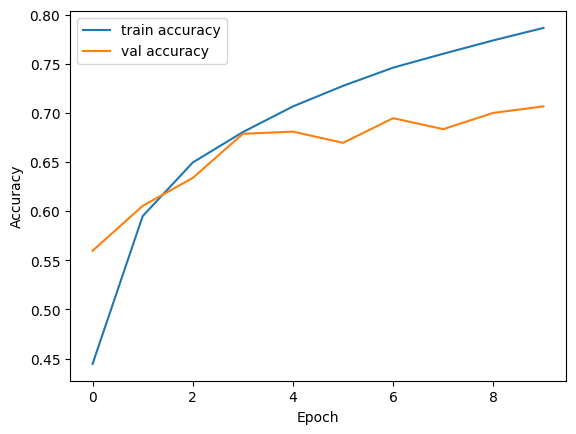

In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

# 1. Load CIFAR-10 — downloads automatically the first time
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# 2. Normalize pixel values from 0-255 to 0-1 (helps the model train faster/better)
train_images, test_images = train_images / 255.0, test_images / 255.0

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# 3. Peek at a few images to confirm the data loaded correctly
plt.figure(figsize=(8, 8))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(train_images[i])
    plt.title(class_names[train_labels[i][0]])
    plt.axis('off')
plt.show()

# 4. Build the CNN: convolution layers extract features, dense layers classify
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10)  # 10 output classes
])

# 5. Compile — tells the model how to learn
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

# 6. Train (10 epochs is enough for a solid deliverable given your timeline)
history = model.fit(
    train_images, train_labels, epochs=10,
    validation_data=(test_images, test_labels)
)

# 7. Evaluate on the held-out test set
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print("Test accuracy:", test_acc)

# 8. Plot accuracy over training — good evidence of "performance evaluation"
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.show()